loading annotations into memory...
Done (t=3.07s)
creating index...
index created!


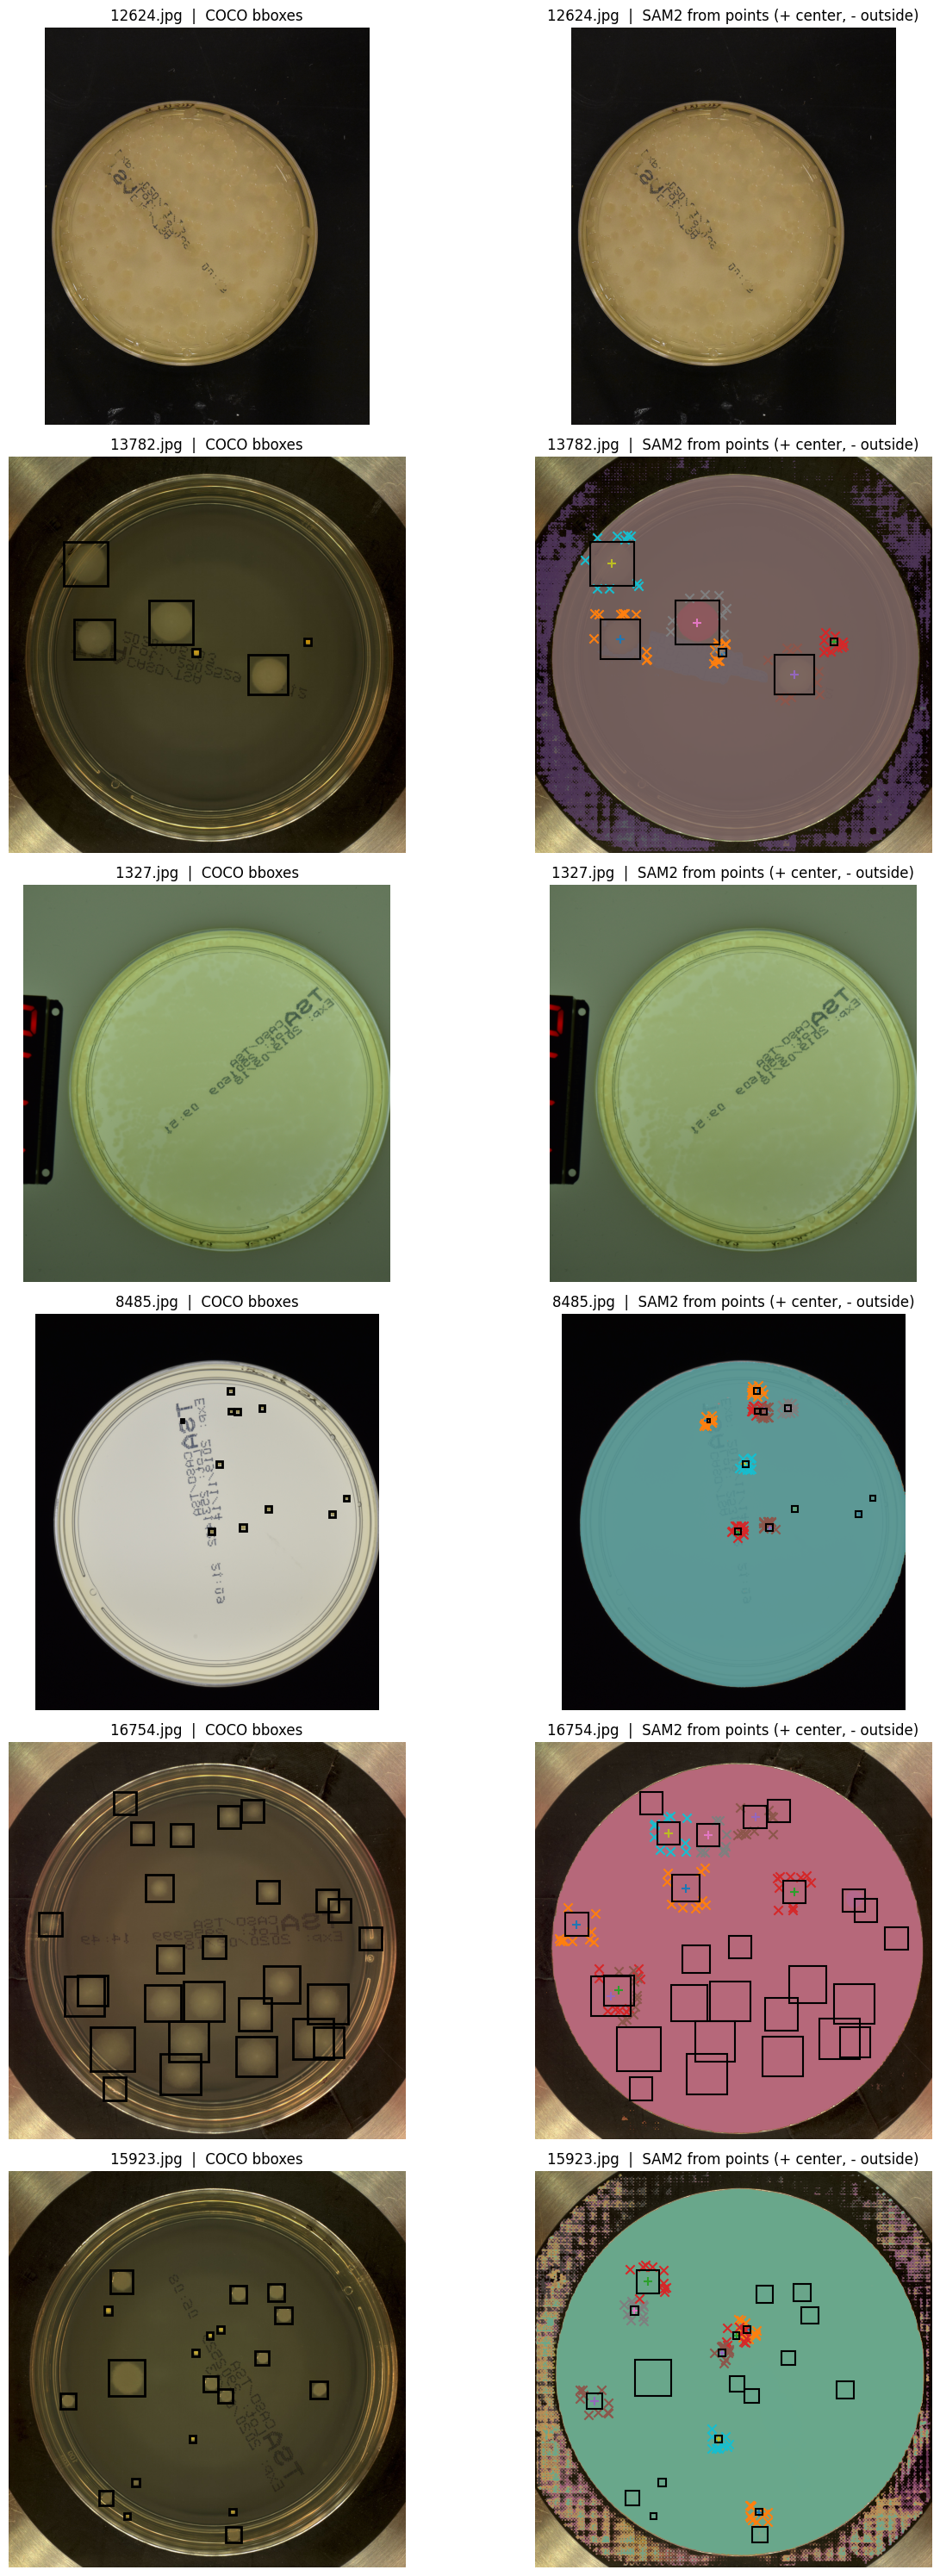

In [1]:
# Notebook cell: COCO data explorer (N random or explicit filenames)
# LEFT: image + COCO bboxes
# RIGHT: Ultralytics SAM2 segmentation using POINT prompts:
#        - 1 positive point at bbox center
#        - K negative points scattered just outside the bbox
#
# pip install -U ultralytics pycocotools opencv-python pillow matplotlib numpy

from __future__ import annotations

import os
import glob
import random
from dataclasses import dataclass
from typing import List, Optional, Sequence, Dict, Tuple, Union

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pycocotools.coco import COCO
from ultralytics import SAM


# -------------------------
# Path / COCO helpers
# -------------------------

COMMON_IMAGE_SUBDIRS = ("images", "img", "train", "val", "valid", "test", "dataset", "data")

def _find_coco_json(dataset_dir: str) -> str:
    jsons = sorted(glob.glob(os.path.join(dataset_dir, "*.json")))
    if not jsons:
        jsons = sorted(glob.glob(os.path.join(dataset_dir, "**", "*.json"), recursive=True))
    if not jsons:
        raise FileNotFoundError(f"No COCO annotation .json found under: {dataset_dir}")
    for cand in jsons:
        name = os.path.basename(cand).lower()
        if "instances" in name or "annotations" in name or "coco" in name:
            return cand
    return jsons[0]

def _resolve_image_path(dataset_dir: str, file_name: str) -> str:
    if os.path.isabs(file_name) and os.path.exists(file_name):
        return file_name

    p = os.path.join(dataset_dir, file_name)
    if os.path.exists(p):
        return p

    for sub in COMMON_IMAGE_SUBDIRS:
        p2 = os.path.join(dataset_dir, sub, file_name)
        if os.path.exists(p2):
            return p2

    base = os.path.basename(file_name)
    matches = glob.glob(os.path.join(dataset_dir, "**", base), recursive=True)
    matches = [m for m in matches if os.path.isfile(m)]
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not resolve image path for COCO file_name='{file_name}' under '{dataset_dir}'")

def _load_rgb(image_path: str) -> np.ndarray:
    return np.array(Image.open(image_path).convert("RGB"))

def _coco_xywh_to_xyxy(b) -> Tuple[float, float, float, float]:
    x, y, w, h = b
    return (x, y, x + w, y + h)


# -------------------------
# Visualization helpers
# -------------------------

def _draw_bboxes(ax, bboxes_xyxy: np.ndarray, linewidth: float = 2.0):
    import matplotlib.patches as patches
    for (x1, y1, x2, y2) in bboxes_xyxy:
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=linewidth)
        ax.add_patch(rect)

def _overlay_masks(ax, masks: np.ndarray, alpha: float = 0.45):
    if masks is None or len(masks) == 0:
        return
    masks = masks.astype(bool)
    h, w = masks.shape[-2], masks.shape[-1]
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2", "C3", "C4"])
    for i, m in enumerate(masks):
        if m.shape != (h, w):
            continue
        color = color_cycle[i % len(color_cycle)]
        overlay = np.zeros((h, w, 4), dtype=np.float32)
        rgb = np.array(plt.matplotlib.colors.to_rgb(color), dtype=np.float32)
        overlay[..., :3] = rgb
        overlay[..., 3] = m.astype(np.float32) * alpha
        ax.imshow(overlay)

def _draw_points(ax, pts_xy: np.ndarray, labels: np.ndarray, size: int = 60):
    """
    labels: 1 for positive, 0 for negative
    """
    if pts_xy is None or len(pts_xy) == 0:
        return
    pts_xy = np.asarray(pts_xy)
    labels = np.asarray(labels).astype(int)
    pos = pts_xy[labels == 1]
    neg = pts_xy[labels == 0]
    if len(pos):
        ax.scatter(pos[:, 0], pos[:, 1], s=size, marker="+")
    if len(neg):
        ax.scatter(neg[:, 0], neg[:, 1], s=size, marker="x")


# -------------------------
# Prompt generation: 1 positive + K negatives outside bbox
# -------------------------

def _sample_negatives_outside_bbox(
    bbox_xyxy: np.ndarray,
    img_w: int,
    img_h: int,
    k: int = 8,
    ring_pad: int = 12,
    ring_thickness: int = 24,
    seed: Optional[int] = None
) -> np.ndarray:
    """
    Samples k points from a "ring" just outside the bbox:
      - Start from an expanded bbox by ring_pad
      - Negatives must be OUTSIDE the original bbox, but inside the expanded bbox
      - ring_thickness controls how far out we allow (expanded bbox is ring_pad + ring_thickness)

    Returns (k,2) points (x,y). If insufficient points found, returns fewer.
    """
    rng = np.random.default_rng(seed)

    x1, y1, x2, y2 = bbox_xyxy.astype(float)
    x1i, y1i, x2i, y2i = x1, y1, x2, y2

    # Outer bbox
    ox1 = max(0.0, x1i - (ring_pad + ring_thickness))
    oy1 = max(0.0, y1i - (ring_pad + ring_thickness))
    ox2 = min(float(img_w - 1), x2i + (ring_pad + ring_thickness))
    oy2 = min(float(img_h - 1), y2i + (ring_pad + ring_thickness))

    # Inner exclusion bbox (original bbox, optionally slightly expanded by ring_pad)
    ix1 = max(0.0, x1i - ring_pad)
    iy1 = max(0.0, y1i - ring_pad)
    ix2 = min(float(img_w - 1), x2i + ring_pad)
    iy2 = min(float(img_h - 1), y2i + ring_pad)

    pts = []
    attempts = 0
    max_attempts = max(200, 50 * k)

    while len(pts) < k and attempts < max_attempts:
        attempts += 1
        x = float(rng.uniform(ox1, ox2))
        y = float(rng.uniform(oy1, oy2))

        # Keep points outside inner bbox (i.e., not near/inside object)
        inside_inner = (ix1 <= x <= ix2) and (iy1 <= y <= iy2)
        if inside_inner:
            continue
        pts.append((x, y))

    return np.array(pts, dtype=np.float32)


def _points_for_bbox(
    bbox_xyxy: np.ndarray,
    img_w: int,
    img_h: int,
    k_neg: int = 8,
    ring_pad: int = 12,
    ring_thickness: int = 24,
    seed: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      points_xy: (1 + k, 2) float32 in pixel coords
      labels: (1 + k,) int where 1=positive, 0=negative
    """
    x1, y1, x2, y2 = bbox_xyxy.astype(float)
    cx = float(np.clip((x1 + x2) / 2.0, 0, img_w - 1))
    cy = float(np.clip((y1 + y2) / 2.0, 0, img_h - 1))
    pos = np.array([[cx, cy]], dtype=np.float32)

    neg = _sample_negatives_outside_bbox(
        bbox_xyxy=bbox_xyxy,
        img_w=img_w,
        img_h=img_h,
        k=k_neg,
        ring_pad=ring_pad,
        ring_thickness=ring_thickness,
        seed=seed
    )

    points = np.vstack([pos, neg]) if len(neg) else pos
    labels = np.array([1] + [0] * len(neg), dtype=np.int32)
    return points, labels


# -------------------------
# SAM2 call: points prompt (robust to minor API variations)
# -------------------------

def _predict_sam2_from_points(
    sam_model: SAM,
    image_rgb: np.ndarray,
    points_xy: np.ndarray,
    point_labels: np.ndarray,
    device: Optional[str] = None,
):
    """
    Runs Ultralytics SAM2 using point prompts.
    Returns masks (N,H,W) bool. Typically N==1 for a single-object prompt.
    """
    H, W = image_rgb.shape[:2]
    if points_xy is None or len(points_xy) == 0:
        return np.zeros((0, H, W), dtype=bool), None

    pts_list = points_xy.tolist()
    lbl_list = point_labels.astype(int).tolist()

    # Try common Ultralytics call patterns.
    # Depending on version, args may be points= / labels= or bboxes= etc.
    results = None
    err = None
    for kwargs in (
        dict(points=pts_list, labels=lbl_list, device=device, verbose=False),
        dict(points=pts_list, point_labels=lbl_list, device=device, verbose=False),
        dict(pts=pts_list, labels=lbl_list, device=device, verbose=False),
    ):
        try:
            results = sam_model.predict(image_rgb, **kwargs)
            err = None
            break
        except TypeError as e:
            err = e
            continue

    if results is None:
        raise RuntimeError(f"Could not call SAM2 with points prompts on this Ultralytics version. Last error: {err}")

    r0 = results[0] if isinstance(results, (list, tuple)) else results
    masks = None
    if hasattr(r0, "masks") and r0.masks is not None:
        data = r0.masks.data
        try:
            import torch
            if isinstance(data, torch.Tensor):
                masks = data.detach().cpu().numpy().astype(bool)
            else:
                masks = np.array(data).astype(bool)
        except Exception:
            masks = np.array(data).astype(bool)

    if masks is None:
        masks = np.zeros((0, H, W), dtype=bool)

    return masks, r0


# -------------------------
# Data extraction
# -------------------------

@dataclass
class COCOImageSample:
    image_id: int
    file_name: str
    image_path: str
    bboxes_xyxy: np.ndarray  # (N,4)


def _get_samples(
    coco: COCO,
    dataset_dir: str,
    image_ids: Sequence[int],
    max_boxes: Optional[int] = None,
    min_box_area: float = 1.0,
) -> List[COCOImageSample]:
    samples = []
    for img_id in image_ids:
        img_info = coco.loadImgs([img_id])[0]
        file_name = img_info["file_name"]
        image_path = _resolve_image_path(dataset_dir, file_name)

        ann_ids = coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = coco.loadAnns(ann_ids)

        bxs = []
        for a in anns:
            if "bbox" not in a:
                continue
            x, y, w, h = a["bbox"]
            if (w * h) < min_box_area:
                continue
            bxs.append(_coco_xywh_to_xyxy(a["bbox"]))

        bboxes = np.array(bxs, dtype=np.float32) if bxs else np.zeros((0, 4), dtype=np.float32)
        if max_boxes is not None and len(bboxes) > max_boxes:
            bboxes = bboxes[:max_boxes]

        samples.append(COCOImageSample(int(img_id), file_name, image_path, bboxes))
    return samples


# -------------------------
# Main explorer
# -------------------------

def show_coco_sam2_points_grid(
    dataset_dir: str,
    n: int = 6,
    filenames: Optional[Sequence[str]] = None,
    seed: int = 0,
    sam2_weights: str = "sam2_b.pt",
    device: Optional[str] = None,
    max_boxes_per_image: Optional[int] = None,
    min_box_area: float = 1.0,
    # point prompt tuning
    k_neg: int = 10,
    ring_pad: int = 12,
    ring_thickness: int = 24,
    # mask aggregation/display
    figsize_per_row: Tuple[float, float] = (14.0, 5.0),
):
    """
    For each selected COCO image:
      LEFT  : image + COCO bboxes
      RIGHT : SAM2 masks from point prompts (per bbox), overlaid on image.
              Prompts per bbox: +center, -negatives outside bbox.
    """
    if not os.path.isabs(dataset_dir):
        raise ValueError("Please provide an absolute path for dataset_dir.")

    ann_path = _find_coco_json(dataset_dir)
    coco = COCO(ann_path)
    sam_model = SAM(sam2_weights)

    all_img_ids = coco.getImgIds()
    if not all_img_ids:
        raise ValueError("No images found in COCO annotations.")

    # Select images
    if filenames and len(filenames) > 0:
        imgs = coco.loadImgs(all_img_ids)
        fname_to_id: Dict[str, int] = {im["file_name"]: int(im["id"]) for im in imgs}
        missing = [f for f in filenames if f not in fname_to_id]
        if missing:
            raise ValueError("Some filenames were not found in COCO annotations:\n" + "\n".join(missing[:25]))
        chosen_ids = [fname_to_id[f] for f in filenames]
    else:
        rng = random.Random(seed)
        chosen_ids = rng.sample(all_img_ids, k=min(n, len(all_img_ids)))

    samples = _get_samples(
        coco=coco,
        dataset_dir=dataset_dir,
        image_ids=chosen_ids,
        max_boxes=max_boxes_per_image,
        min_box_area=min_box_area
    )

    # Plot
    num_rows = len(samples)
    fig_w, fig_h = figsize_per_row
    fig, axes = plt.subplots(num_rows, 2, figsize=(fig_w, fig_h * num_rows), squeeze=False)

    for row, s in enumerate(samples):
        image_rgb = _load_rgb(s.image_path)
        H, W = image_rgb.shape[:2]
        title = os.path.basename(s.file_name)

        # LEFT: bbox view
        axL = axes[row, 0]
        axL.imshow(image_rgb)
        if len(s.bboxes_xyxy) > 0:
            _draw_bboxes(axL, s.bboxes_xyxy)
        axL.set_title(f"{title}  |  COCO bboxes")
        axL.axis("off")

        # RIGHT: SAM2 from points (per bbox)
        axR = axes[row, 1]
        axR.imshow(image_rgb)

        all_masks = []
        # Optional: show prompt points for the first few boxes to avoid clutter
        show_points_for_first = min(8, len(s.bboxes_xyxy))

        for bi, bbox in enumerate(s.bboxes_xyxy):
            pts, lbls = _points_for_bbox(
                bbox_xyxy=bbox,
                img_w=W,
                img_h=H,
                k_neg=k_neg,
                ring_pad=ring_pad,
                ring_thickness=ring_thickness,
                seed=(seed + row * 10_000 + bi)
            )

            masks, _ = _predict_sam2_from_points(
                sam_model=sam_model,
                image_rgb=image_rgb,
                points_xy=pts,
                point_labels=lbls,
                device=device
            )

            # Typically masks.shape[0] == 1 for a single-object prompt; keep the largest mask if multiple.
            if masks.shape[0] > 0:
                if masks.shape[0] > 1:
                    areas = masks.reshape(masks.shape[0], -1).sum(axis=1)
                    masks = masks[np.argsort(-areas)]  # largest first
                all_masks.append(masks[0])

            if bi < show_points_for_first:
                _draw_points(axR, pts, lbls, size=55)

        if len(all_masks) > 0:
            mask_stack = np.stack(all_masks, axis=0).astype(bool)
            _overlay_masks(axR, mask_stack, alpha=0.45)

        if len(s.bboxes_xyxy) > 0:
            _draw_bboxes(axR, s.bboxes_xyxy, linewidth=1.5)

        axR.set_title(f"{title}  |  SAM2 from points (+ center, - outside)")
        axR.axis("off")

    plt.tight_layout()
    plt.show()


# -------------------------
# Example usage
# -------------------------

# Random N images:
show_coco_sam2_points_grid(
    dataset_dir="D:/AGAR_dataset/AGAR_dataset/dataset",
    n=6,
    sam2_weights="sam2_b.pt",
    device="cuda",
    max_boxes_per_image=50,
    k_neg=10,
    ring_pad=12,
    ring_thickness=24,
)

# Specific filenames (must match COCO 'file_name' exactly):
# show_coco_sam2_points_grid(
#     dataset_dir="/absolute/path/to/your/coco_folder",
#     filenames=["train/000001.png", "train/000002.png"],
#     sam2_weights="sam2_b.pt",
#     device="cuda",
#     k_neg=12,
# )


In [ ]:
# Notebook cell: Batch SAM2 -> 16-bit instance-id masks + YOLO-SEG labels
#               Using per-bbox ROI segmentation + bbox clipping (reduces small-object merging)
#
# pip install -U ultralytics pycocotools opencv-python pillow numpy

from __future__ import annotations

import os
import json
import glob
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
from PIL import Image
import cv2

from pycocotools.coco import COCO
from ultralytics import SAM


# -----------------------------
# COCO path helpers
# -----------------------------

COMMON_IMAGE_SUBDIRS = ("images", "img", "train", "val", "valid", "test", "dataset", "data")

def find_coco_json(dataset_dir: str) -> str:
    jsons = sorted(glob.glob(os.path.join(dataset_dir, "*.json")))
    if not jsons:
        jsons = sorted(glob.glob(os.path.join(dataset_dir, "**", "*.json"), recursive=True))
    if not jsons:
        raise FileNotFoundError(f"No COCO .json found under: {dataset_dir}")

    for cand in jsons:
        name = os.path.basename(cand).lower()
        if "instances" in name or "annotations" in name or "coco" in name:
            return cand
    return jsons[0]


def resolve_image_path(dataset_dir: str, file_name: str) -> str:
    if os.path.isabs(file_name) and os.path.exists(file_name):
        return file_name

    p = os.path.join(dataset_dir, file_name)
    if os.path.exists(p):
        return p

    for sub in COMMON_IMAGE_SUBDIRS:
        p2 = os.path.join(dataset_dir, sub, file_name)
        if os.path.exists(p2):
            return p2

    base = os.path.basename(file_name)
    matches = glob.glob(os.path.join(dataset_dir, "**", base), recursive=True)
    matches = [m for m in matches if os.path.isfile(m)]
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Cannot resolve image file_name='{file_name}' under '{dataset_dir}'")


def load_rgb(image_path: str) -> np.ndarray:
    return np.array(Image.open(image_path).convert("RGB"))


def coco_xywh_to_xyxy(b: Sequence[float]) -> List[float]:
    x, y, w, h = b
    return [x, y, x + w, y + h]


# -----------------------------
# Ultralytics SAM2 wrappers
# -----------------------------

def predict_sam2_from_bboxes(
    sam_model: SAM,
    image_rgb: np.ndarray,
    bboxes_xyxy: np.ndarray,
    device: Optional[str] = None,
) -> np.ndarray:
    """
    Predict masks for one image and one-or-many bbox prompts.
    Returns masks: (N,H,W) boolean
    """
    H, W = image_rgb.shape[:2]
    if bboxes_xyxy is None or len(bboxes_xyxy) == 0:
        return np.zeros((0, H, W), dtype=bool)

    bboxes_list = bboxes_xyxy.tolist()

    try:
        results = sam_model.predict(image_rgb, bboxes=bboxes_list, device=device, verbose=False)
    except TypeError:
        results = sam_model(image_rgb, bboxes=bboxes_list, device=device, verbose=False)

    r0 = results[0] if isinstance(results, (list, tuple)) else results
    if getattr(r0, "masks", None) is None or r0.masks is None:
        return np.zeros((0, H, W), dtype=bool)

    data = r0.masks.data
    try:
        import torch
        if isinstance(data, torch.Tensor):
            masks = data.detach().cpu().numpy().astype(bool)
        else:
            masks = np.array(data).astype(bool)
    except Exception:
        masks = np.array(data).astype(bool)

    if masks.ndim == 2:
        masks = masks[None, ...]
    return masks


# -----------------------------
# Per-bbox ROI segmentation + bbox clipping (drop-in)
# -----------------------------

def shrink_bbox_xyxy(b: np.ndarray, shrink: float, W: int, H: int) -> np.ndarray:
    """
    shrink: 0.0 means no shrink, 0.1 means shrink each side inward by 10% of bbox size.
    bbox is xyxy in pixel coordinates.
    """
    x1, y1, x2, y2 = b.astype(np.float32)
    w = max(1.0, x2 - x1)
    h = max(1.0, y2 - y1)
    dx = 0.5 * shrink * w
    dy = 0.5 * shrink * h
    nx1 = np.clip(x1 + dx, 0, W - 1)
    ny1 = np.clip(y1 + dy, 0, H - 1)
    nx2 = np.clip(x2 - dx, 1, W)
    ny2 = np.clip(y2 - dy, 1, H)
    # avoid collapse
    if nx2 <= nx1 + 1:
        nx1, nx2 = x1, x2
    if ny2 <= ny1 + 1:
        ny1, ny2 = y1, y2
    return np.array([nx1, ny1, nx2, ny2], dtype=np.float32)


def pad_bbox_xyxy(b: np.ndarray, pad: int, W: int, H: int) -> np.ndarray:
    x1, y1, x2, y2 = b.astype(np.int32)
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(W, x2 + pad)
    y2 = min(H, y2 + pad)
    return np.array([x1, y1, x2, y2], dtype=np.int32)


def predict_sam2_per_bbox_roi(
    sam_model: SAM,
    image_rgb: np.ndarray,
    bboxes_xyxy: np.ndarray,
    device: Optional[str] = None,
    shrink: float = 0.10,
    roi_pad: int = 24,
    clip_to_bbox_pad: int = 4,
    max_area_ratio: float = 2.0,
) -> np.ndarray:
    """
    Returns (N,H,W) boolean masks, one per input bbox.
    Approach:
      - shrink bbox (optional) to tighten prompt
      - crop ROI around bbox with padding (reduces context, reduces merging)
      - run SAM2 with single bbox prompt in ROI
      - clip resulting mask to bbox +/- pad (prevents spill)
      - reject masks far larger than bbox (merged-object signature)
    """
    H, W = image_rgb.shape[:2]
    N = bboxes_xyxy.shape[0]
    out = np.zeros((N, H, W), dtype=bool)

    for i in range(N):
        b = bboxes_xyxy[i].copy()

        b_shrunk = shrink_bbox_xyxy(b, shrink=shrink, W=W, H=H)

        roi = pad_bbox_xyxy(b_shrunk, pad=roi_pad, W=W, H=H)
        rx1, ry1, rx2, ry2 = roi
        crop = image_rgb[ry1:ry2, rx1:rx2]
        if crop.size == 0:
            continue

        # bbox within crop coords
        cb = b_shrunk.copy()
        cb[0] -= rx1; cb[2] -= rx1
        cb[1] -= ry1; cb[3] -= ry1

        masks_crop = predict_sam2_from_bboxes(
            sam_model=sam_model,
            image_rgb=crop,
            bboxes_xyxy=np.array([cb], dtype=np.float32),
            device=device,
        )
        if masks_crop.shape[0] == 0:
            continue

        m = masks_crop[0].astype(bool)

        # Clip to bbox region (within crop) to stop merges / bleed
        cb_int = pad_bbox_xyxy(cb, pad=clip_to_bbox_pad, W=crop.shape[1], H=crop.shape[0])
        cx1, cy1, cx2, cy2 = cb_int
        clip_mask = np.zeros_like(m, dtype=bool)
        clip_mask[cy1:cy2, cx1:cx2] = True
        m = m & clip_mask

        # Reject masks that are much larger than the bbox
        bbox_area = max(1.0, float((cb[2] - cb[0]) * (cb[3] - cb[1])))
        mask_area = float(m.sum())
        if bbox_area > 0 and (mask_area / bbox_area) > max_area_ratio:
            continue

        out[i, ry1:ry2, rx1:rx2] = m

    return out


# -----------------------------
# Output formats
# -----------------------------

def save_instance_id_mask(
    masks: np.ndarray,
    out_path: str,
    overlap_policy: str = "small_overwrites",
) -> np.ndarray:
    """
    Creates 16-bit instance-id mask: 0=bg, 1..N=instances.
    overlap_policy:
      - "small_overwrites": smaller area masks overwrite larger
      - "large_overwrites": larger overwrite smaller
      - "first_wins": first mask keeps pixels, later overlaps ignored
      - "last_wins": later masks overwrite earlier (no sorting)
    """
    if masks.ndim != 3:
        raise ValueError("masks must be (N,H,W)")
    n, h, w = masks.shape
    inst = np.zeros((h, w), dtype=np.uint16)
    if n == 0:
        Image.fromarray(inst, mode="I;16").save(out_path)
        return inst

    areas = masks.reshape(n, -1).sum(axis=1)
    if overlap_policy == "small_overwrites":
        order = np.argsort(areas)  # asc
    elif overlap_policy == "large_overwrites":
        order = np.argsort(-areas)  # desc
    elif overlap_policy == "first_wins":
        order = np.arange(n)
    elif overlap_policy == "last_wins":
        order = np.arange(n)
    else:
        raise ValueError(f"Unknown overlap_policy: {overlap_policy}")

    if overlap_policy == "first_wins":
        for idx in order:
            m = masks[idx]
            writeable = (inst == 0) & m
            inst[writeable] = idx + 1
    else:
        for idx in order:
            inst[masks[idx]] = idx + 1

    Image.fromarray(inst, mode="I;16").save(out_path)
    return inst


def instance_mask_to_yolo_polygon_line(
    instance_binary_mask: np.ndarray,
    class_id: int,
    eps_frac: float = 0.002,
    min_area: float = 4.0,
    keep_largest_contour: bool = True,
) -> Optional[str]:
    """
    Convert a single instance mask -> YOLO-SEG polygon label line:
      <class_id> x1 y1 x2 y2 ... (normalized)
    """
    m = (instance_binary_mask.astype(np.uint8) * 255)
    h, w = m.shape[:2]

    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    if keep_largest_contour:
        contours = [max(contours, key=cv2.contourArea)]

    cnt = contours[0]
    area = float(cv2.contourArea(cnt))
    if area < min_area:
        return None

    eps = eps_frac * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, eps, True).reshape(-1, 2)
    if approx.shape[0] < 3:
        return None

    pts = []
    for (x, y) in approx:
        pts.append(f"{x / w:.6f}")
        pts.append(f"{y / h:.6f}")

    return f"{class_id} " + " ".join(pts)


# -----------------------------
# Main batch script
# -----------------------------

def sam2_coco_to_instmask_and_yoloseg_roi(
    dataset_dir: str,
    out_dir: str,
    sam2_weights: str = "sam2_b.pt",
    device: Optional[str] = None,
    # bbox filtering
    min_box_area: float = 1.0,
    max_boxes_per_image: Optional[int] = None,
    # polygon simplification
    eps_frac: float = 0.002,
    # ROI segmentation + clipping
    shrink: float = 0.10,
    roi_pad: int = 24,
    clip_to_bbox_pad: int = 4,
    max_area_ratio: float = 2.0,
    # instance-id overlap resolution
    overlap_policy: str = "small_overwrites",
    # files
    write_empty_label_files: bool = True,
):
    """
    Produces:
      out_dir/
        masks_16bit/<stem>_inst.png         (uint16 instance id mask)
        labels_yoloseg/<stem>.txt           (YOLO-SEG polygon labels)
        meta/<stem>.json                    (per-image mapping instance_id -> class/category etc.)
        classes.json                         (YOLO class list)
        category_id_to_class_id.json         (COCO category id -> YOLO class id)
    """
    if not os.path.isabs(dataset_dir):
        raise ValueError("dataset_dir must be an absolute path.")
    os.makedirs(out_dir, exist_ok=True)

    masks_dir = os.path.join(out_dir, "masks_16bit")
    labels_dir = os.path.join(out_dir, "labels_yoloseg")
    meta_dir = os.path.join(out_dir, "meta")
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(meta_dir, exist_ok=True)

    ann_path = find_coco_json(dataset_dir)
    coco = COCO(ann_path)

    # Stable mapping COCO category_id -> YOLO class_id
    cats = coco.loadCats(coco.getCatIds())
    cats = sorted(cats, key=lambda c: int(c["id"]))
    category_id_to_class_id: Dict[int, int] = {int(c["id"]): i for i, c in enumerate(cats)}
    classes: List[str] = [c.get("name", str(c["id"])) for c in cats]

    with open(os.path.join(out_dir, "category_id_to_class_id.json"), "w") as f:
        json.dump(category_id_to_class_id, f, indent=2)
    with open(os.path.join(out_dir, "classes.json"), "w") as f:
        json.dump(classes, f, indent=2)

    sam_model = SAM(sam2_weights)

    img_ids = coco.getImgIds()
    total = len(img_ids)
    if total == 0:
        raise ValueError("No images found in COCO annotation.")

    for i, img_id in enumerate(img_ids, start=1):
        img_info = coco.loadImgs([img_id])[0]
        file_name = img_info["file_name"]
        stem = os.path.splitext(os.path.basename(file_name))[0]

        image_path = resolve_image_path(dataset_dir, file_name)
        image_rgb = load_rgb(image_path)
        H, W = image_rgb.shape[:2]

        ann_ids = coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = coco.loadAnns(ann_ids)

        bboxes = []
        cat_ids = []
        ann_ids_kept = []

        for a in anns:
            if "bbox" not in a:
                continue
            x, y, w, h = a["bbox"]
            if (w * h) < min_box_area:
                continue
            bboxes.append(coco_xywh_to_xyxy(a["bbox"]))
            cat_ids.append(int(a.get("category_id", -1)))
            ann_ids_kept.append(int(a.get("id", -1)))

        bboxes_xyxy = np.array(bboxes, dtype=np.float32) if bboxes else np.zeros((0, 4), dtype=np.float32)

        if max_boxes_per_image is not None and len(bboxes_xyxy) > max_boxes_per_image:
            bboxes_xyxy = bboxes_xyxy[:max_boxes_per_image]
            cat_ids = cat_ids[:max_boxes_per_image]
            ann_ids_kept = ann_ids_kept[:max_boxes_per_image]

        # --- Key change: per-bbox ROI segmentation + bbox clipping ---
        masks = predict_sam2_per_bbox_roi(
            sam_model=sam_model,
            image_rgb=image_rgb,
            bboxes_xyxy=bboxes_xyxy,
            device=device,
            shrink=shrink,
            roi_pad=roi_pad,
            clip_to_bbox_pad=clip_to_bbox_pad,
            max_area_ratio=max_area_ratio,
        )

        # Save instance-id mask
        inst_path = os.path.join(masks_dir, f"{stem}_inst.png")
        inst_u16 = save_instance_id_mask(masks, inst_path, overlap_policy=overlap_policy)

        # Build YOLO-SEG labels (one per instance) + meta mapping
        label_lines: List[str] = []
        instances_meta: List[Dict] = []

        num_instances = int(inst_u16.max())
        for inst_id in range(1, num_instances + 1):
            idx0 = inst_id - 1  # because we made instance ids from mask index + 1
            if idx0 >= len(cat_ids):
                continue

            coco_cat = int(cat_ids[idx0])
            if coco_cat not in category_id_to_class_id:
                continue
            class_id = int(category_id_to_class_id[coco_cat])

            bin_mask = (inst_u16 == inst_id)
            line = instance_mask_to_yolo_polygon_line(
                instance_binary_mask=bin_mask,
                class_id=class_id,
                eps_frac=eps_frac,
                min_area=4.0,
                keep_largest_contour=True,
            )
            if line is not None:
                label_lines.append(line)

            instances_meta.append({
                "instance_id": int(inst_id),
                "coco_category_id": coco_cat,
                "yolo_class_id": class_id,
                "source_bbox_xyxy": [float(x) for x in bboxes_xyxy[idx0].tolist()] if idx0 < len(bboxes_xyxy) else None,
                "source_ann_id": int(ann_ids_kept[idx0]) if idx0 < len(ann_ids_kept) else None,
            })

        # Write label file
        label_path = os.path.join(labels_dir, f"{stem}.txt")
        if label_lines or write_empty_label_files:
            with open(label_path, "w") as f:
                f.write("\n".join(label_lines) + ("\n" if label_lines else ""))

        # Write per-image meta JSON
        meta_path = os.path.join(meta_dir, f"{stem}.json")
        meta = {
            "image_id": int(img_id),
            "file_name": file_name,
            "image_path": image_path,
            "width": int(W),
            "height": int(H),
            "instance_mask_16bit": os.path.basename(inst_path),
            "num_instances": int(num_instances),
            "instances": instances_meta,
            "roi_method": {
                "shrink": float(shrink),
                "roi_pad": int(roi_pad),
                "clip_to_bbox_pad": int(clip_to_bbox_pad),
                "max_area_ratio": float(max_area_ratio),
            },
        }
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)

        if i % 50 == 0 or i == total:
            print(f"[{i}/{total}] processed")

    print("Done.")
    print(f"Instance masks (16-bit): {masks_dir}")
    print(f"YOLO-SEG labels:         {labels_dir}")
    print(f"Metadata JSON:           {meta_dir}")
    print(f"Classes:                 {os.path.join(out_dir, 'classes.json')}")


# -----------------------------
# Example run
# -----------------------------
sam2_coco_to_instmask_and_yoloseg_roi(
    dataset_dir="D:/AGAR_dataset/AGAR_dataset/dataset",
    out_dir="D:/AGAR_dataset/AGAR_dataset/yoloseg_output_smaller",
    sam2_weights="sam2_b.pt",
    device="cuda",          # or "cpu" / "mps"
    # Polygon simplification:
    eps_frac=0.003,
    # ROI anti-merge controls:
    shrink=0.12,
    roi_pad=20,
    clip_to_bbox_pad=4,
    max_area_ratio=2.0,
    # Optional:
    max_boxes_per_image=200,
)


loading annotations into memory...
Done (t=3.96s)
creating index...
index created!


C:\Users\3i\AppData\Local\Temp\ipykernel_23168\2784639832.py:241: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(inst, mode="I;16").save(out_path)


[50/18000] processed
[100/18000] processed
[150/18000] processed
[200/18000] processed
[250/18000] processed
[300/18000] processed


C:\Users\3i\AppData\Local\Temp\ipykernel_23168\2784639832.py:265: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(inst, mode="I;16").save(out_path)
